<a href="https://colab.research.google.com/github/nithinrb/Emotion-analyzer/blob/main/DAY3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
inputs = np.array([1, 2, 3])
weights = np.array([0.2, 0.8, -0.5])
bias = 2
output = np.dot(inputs, weights) + bias
print("Neuron Output:", output)

Neuron Output: 2.3


In [ ]:
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
x = 2
print("Sigmoid Output:", sigmoid(x))

Sigmoid Output: 0.8807970779778823


In [ ]:
from sklearn.neural_network import MLPClassifier
X = [[0,0],
     [0,1],
     [1,0],
     [1,1]]
y = [0,1,1,0]
model = MLPClassifier(hidden_layer_sizes=(4,),
                      max_iter=5000,
                      random_state=42)
model.fit(X, y)
print("Predictions:")
print(model.predict(X))

Predictions:
[0 0 0 0]


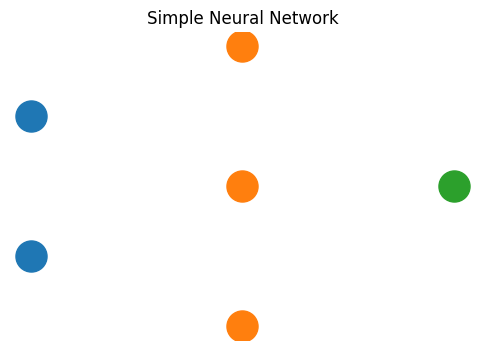

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter([1,1],[1,2],s=500)
plt.scatter([3,3,3],[0.5,1.5,2.5],s=500)
plt.scatter([5],[1.5],s=500)
plt.title("Simple Neural Network")
plt.axis('off')
plt.show()


TensorFlow Version: 2.20.0
GPU Available: []
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7765 - loss: 0.6279 - val_accuracy: 0.8453 - val_loss: 0.4172
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8466 - loss: 0.4246 - val_accuracy: 0.8628 - val_loss: 0.3794
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8610 - loss: 0.3822 - val_accuracy: 0.8687 - val_loss: 0.3560
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8691 - loss: 0.3575 - val_accuracy: 0.8687 - val_loss: 0.3557
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8758 - loss: 0.3405 - val_accuracy: 0.8702 - val_loss: 0.3519
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8801 - loss: 0.3244 - val_accuracy: 0.8759 - val_loss: 0.3408
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8830 - loss: 0.3135 - val_accuracy: 0.8813 - val_loss: 0.3236
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8864 - loss: 0.3043 - val_accuracy: 

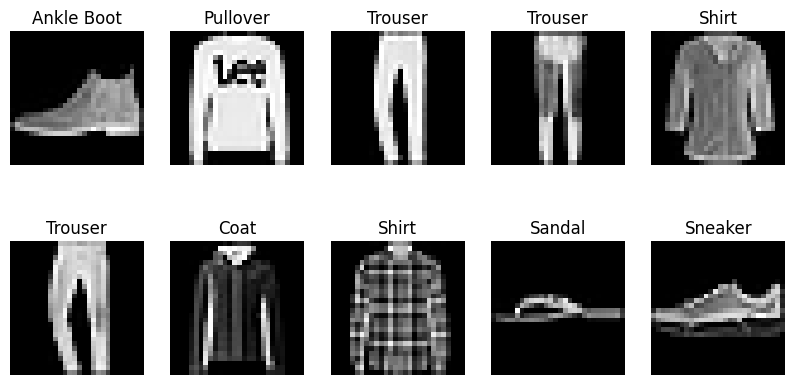

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Load Fashion-MNIST Dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model on GPU
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_classes))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_classes))

class_names = [
    'T-shirt','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag','Ankle Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')

plt.show()



TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.

Classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


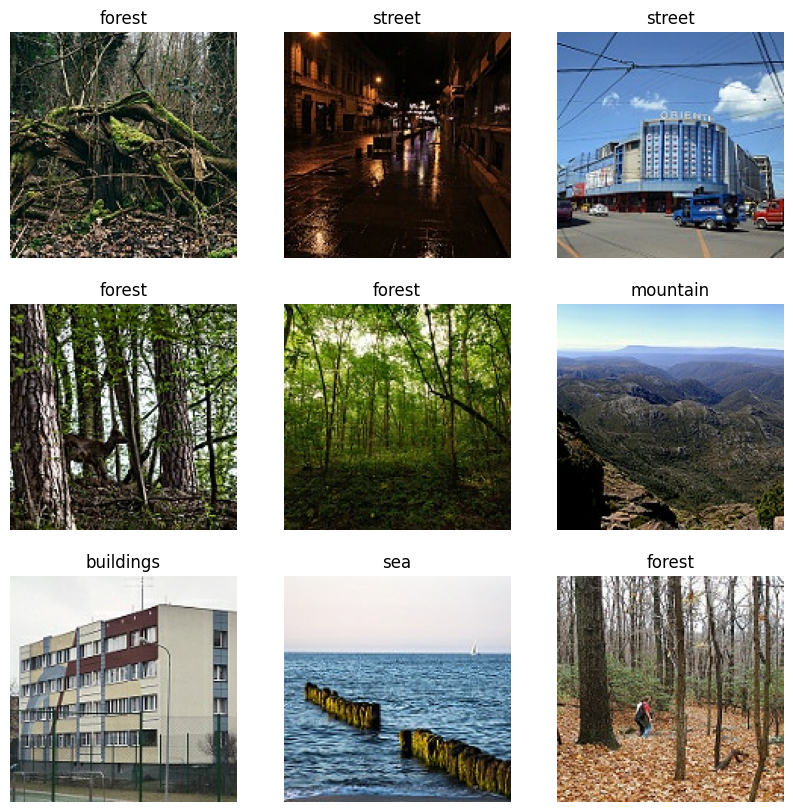

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.6037 - loss: 1.0341 - val_accuracy: 0.6450 - val_loss: 0.9338
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.7450 - loss: 0.6960 - val_accuracy: 0.7491 - val_loss: 0.7240
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7924 - loss: 0.5758 - val_accuracy: 0.7798 - val_loss: 0.5829
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8285 - loss: 0.4762 - val_accuracy: 0.8097 - val_loss: 0.5435
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8673 - loss: 0.3764 - val_accuracy: 0.8261 - val_loss: 0.5855
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8885 - loss: 0.3134 - val_accuracy: 0.8311 - val_loss: 0.6071
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9132 - loss: 0.2469 - val_accuracy: 0.8329 - val_loss: 0.6138
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9258 - loss: 0.2075 - v

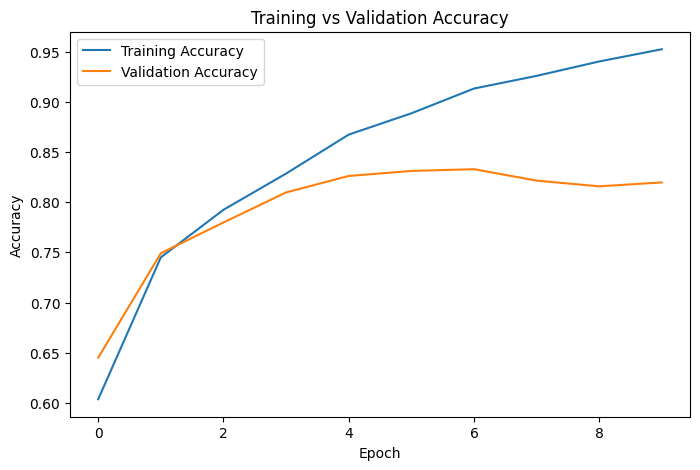

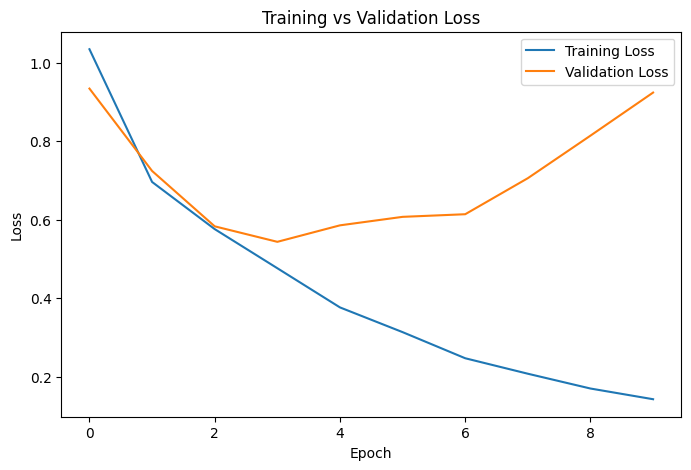

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

Confusion Matrix
[[368   5   7   7   7  43]
 [  5 460   2   5   0   2]
 [ 12   6 445  71  17   2]
 [  9   4  83 402  26   1]
 [ 22   2  47  39 394   6]
 [ 82  13   4   3   5 394]]

Classification Report
              precision    recall  f1-score   support

   buildings       0.74      0.84      0.79       437
      forest       0.94      0.97      0.95       474
     glacier       0.76      0.80      0.78       553
    mountain       0.76      0.77      0.76       525
         sea       0.88      0.77      0.82       510
      street       0.88      0.79      0.83       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.83      0.82      0.82      3000

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


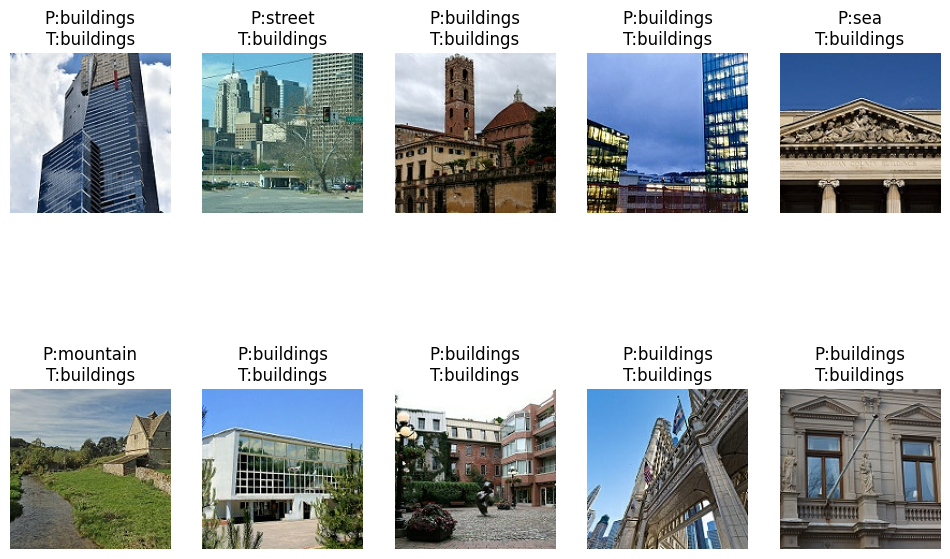

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ==========================
# Check GPU
# ==========================
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# ==========================
# Dataset Paths
# ==========================
train_path = '/content/intel/seg_train/seg_train'
test_path = '/content/intel/seg_test/seg_test'

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# ==========================
# Load Training Dataset
# ==========================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses:")
print(class_names)

# ==========================
# Show Sample Images
# ==========================
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# ==========================
# CNN Model
# ==========================
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255,
                              input_shape=(150,150,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(6, activation='softmax')
])

model.summary()

# ==========================
# Compile Model
# ==========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================
# Train Model
# ==========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ==========================
# Evaluate Model
# ==========================
test_loss, test_accuracy = model.evaluate(test_ds)

print("\nTest Accuracy:", test_accuracy)

# ==========================
# Accuracy Graph
# ==========================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# ==========================
# Loss Graph
# ==========================
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ==========================
# Predictions
# ==========================
y_true = np.concatenate(
    [labels.numpy() for images, labels in test_ds]
)

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix")
print(cm)

# ==========================
# Classification Report
# ==========================
print("\nClassification Report")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

# ==========================
# Sample Predictions
# ==========================
plt.figure(figsize=(12,8))

for images, labels in test_ds.take(1):

    predictions = model.predict(images)

    for i in range(10):

        plt.subplot(2,5,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        pred_label = class_names[
            np.argmax(predictions[i])
        ]

        true_label = class_names[labels[i]]

        plt.title(f"P:{pred_label}\nT:{true_label}")
        plt.axis('off')

plt.show()

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7812 - loss: 0.5456 - val_accuracy: 0.9375 - val_loss: 0.4208
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9625 - loss: 0.3350 - val_accuracy: 0.9625 - val_loss: 0.2781
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9719 - loss: 0.2207 - val_accuracy: 0.9625 - val_loss: 0.2022
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9719 - loss: 0.1607 - val_accuracy: 0.9625 - val_loss: 0.1631
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9719 - loss: 0.1287 - val_accuracy: 0.9625 - val_loss: 0.1401
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9719 - loss: 0.1102 - val_accuracy: 0.9625 - val_loss: 0.1263
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9719 - loss: 0.0989 - val_accuracy: 0.9625 - val_loss: 0.1169
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9719 - loss: 0.0909 - val_accuracy: 0.9625 - val_loss

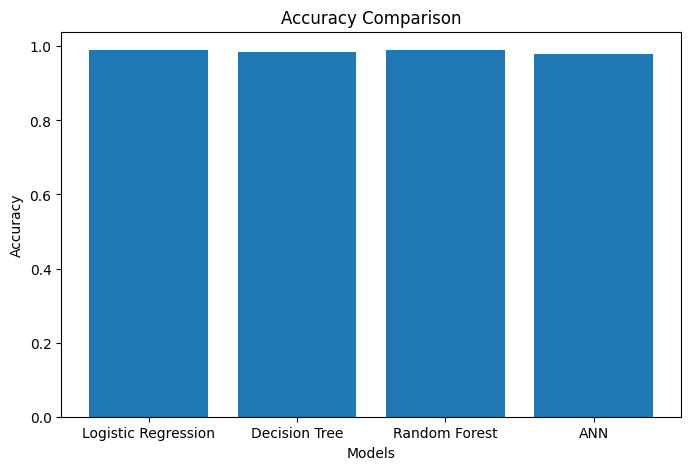

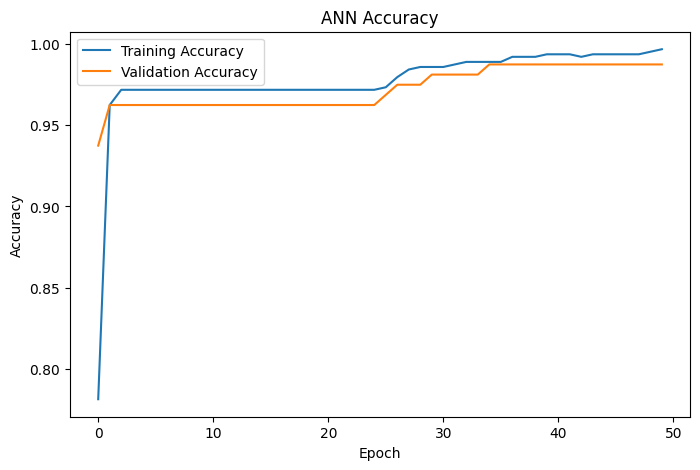

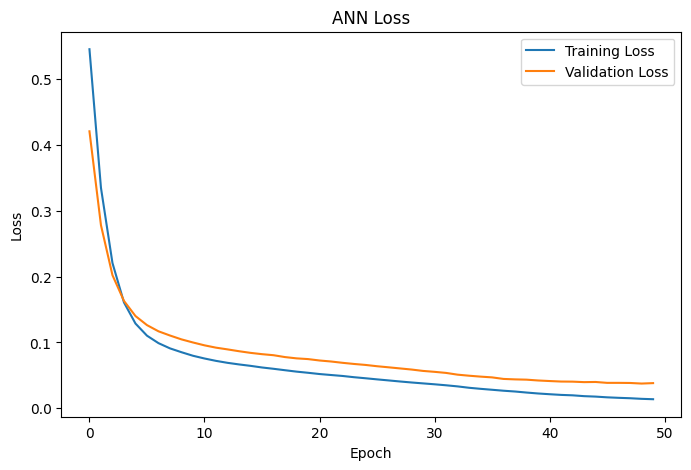

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================
# Load Dataset
# ==========================
data = pd.read_csv('/content/StudentsPerformance.csv')

print(data.head())

# ==========================
# Create Pass/Fail Target
# ==========================
data['Pass'] = np.where(
    data['writing score'] >= 40,
    1,
    0
)

# ==========================
# Encode Categorical Columns
# ==========================
encoder = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = encoder.fit_transform(data[col])

# ==========================
# Features and Target
# ==========================
X = data.drop(['writing score', 'Pass'], axis=1)

y = data['Pass']

# ==========================
# Scale Features
# ==========================
scaler = StandardScaler()

X = scaler.fit_transform(X)

# ==========================
# Train Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# Logistic Regression
# ==========================
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

# ==========================
# Decision Tree
# ==========================
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

# ==========================
# Random Forest
# ==========================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

# ==========================
# ANN Model
# ==========================
ann = Sequential([
    Dense(16, activation='relu',
          input_shape=(X_train.shape[1],)),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

ann_pred = ann.predict(X_test)

ann_pred = (ann_pred > 0.5).astype(int)

ann_acc = accuracy_score(
    y_test,
    ann_pred
)

# ==========================
# Print Results
# ==========================
print("\nAccuracy Comparison")
print("----------------------")

print("Logistic Regression :", lr_acc)
print("Decision Tree       :", dt_acc)
print("Random Forest       :", rf_acc)
print("ANN                 :", ann_acc)

# ==========================
# Accuracy Comparison Graph
# ==========================
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'ANN'
]

accuracies = [
    lr_acc,
    dt_acc,
    rf_acc,
    ann_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Models')

plt.show()

# ==========================
# ANN Accuracy Graph
# ==========================
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

# ==========================
# ANN Loss Graph
# ==========================
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()